# Data Preprocessing

## Data Loading (TODO: Access from Google Drive)

In [48]:
import pandas as pd

df = pd.read_csv("../data/air_quality.csv")

In [49]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34139 non-null  float64
 6   PM10     34346 non-null  float64
 7   SO2      34129 non-null  float64
 8   NO2      34041 non-null  float64
 9   CO       33288 non-null  float64
 10  O3       33345 non-null  float64
 11  TEMP     35044 non-null  float64
 12  PRES     35044 non-null  float64
 13  DEWP     35044 non-null  float64
 14  RAIN     35044 non-null  float64
 15  wd       34983 non-null  str    
 16  WSPM     35050 non-null  float64
 17  station  35064 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 4.8 MB


In [51]:
df.isnull().sum()

No            0
year          0
month         0
day           0
hour          0
PM2.5       925
PM10        718
SO2         935
NO2        1023
CO         1776
O3         1719
TEMP         20
PRES         20
DEWP         20
RAIN         20
wd           81
WSPM         14
station       0
dtype: int64

## Datetime (TODO: Handle missing values better)

In [52]:
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.drop(columns=["No"])
df = df.sort_values("datetime")
df = df.set_index("datetime")

ts = df["PM2.5"]
ts = ts.interpolate()

# Time Series Analysis

## Visualizations

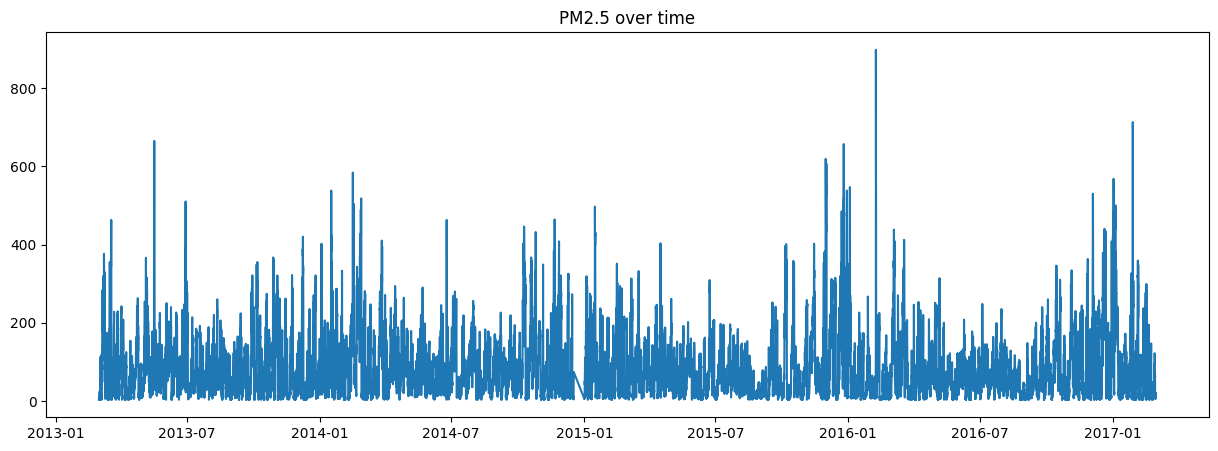

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(ts)
plt.title("PM2.5 over time")
plt.show()

When looking at the full picture (data from 2013 to 2017) we can see that there is a clear yearly pattern. During the winter months, each time a year ends or starts, the high peak frequency or the PM2.5 concentration spikes. This confirms our theory that air pollution levels would go up in these dates because of the use of heaters.

Extreme outliers are also visible. The variance of the series is very big. The limit of 600 $\mu g/m^3$ is passed several times, in fact, when 2015 was ending and 2016 was starting an anomalous event happended that caused to reach almost 900 $\mu g/m^3$.

Lastly, it is clear that the series is not stationary. The mean does not stay constant through time (it oscillates between summer and winter) and the variance changes a lot depending on the season of the year.

<Axes: xlabel='datetime'>

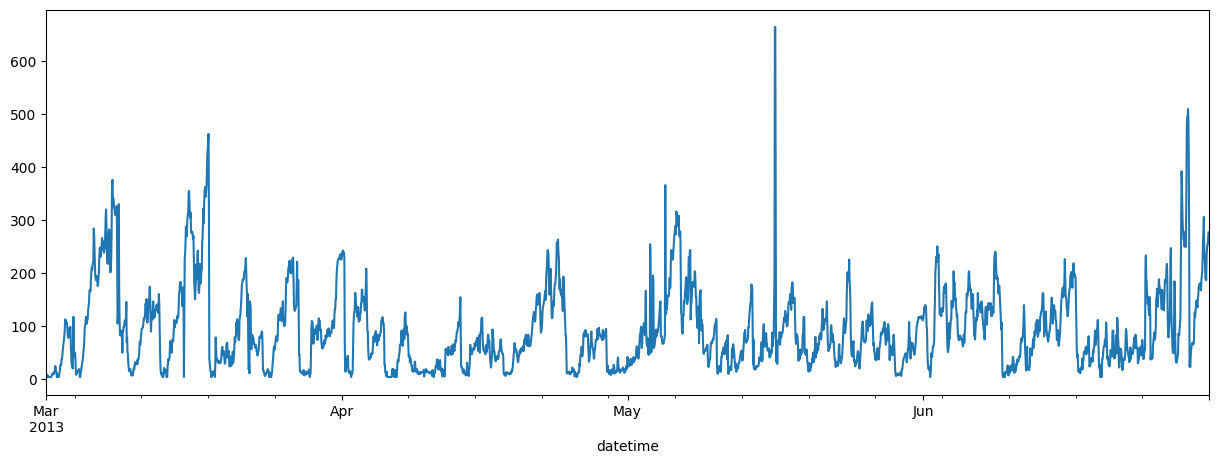

In [54]:
ts.loc["2013-03":"2013-06"].plot(figsize=(15,5))

When zooming into a shorter period (from March, 2013 to June, 2013) we remove the annual tendency to be able to see it in "shorter terms".

We can see that pollution does not fluctuate in a smooth way, it accumulates progressively during several days and suddenly it falls to almost zero. This could confirm another theory we had that washing events such as rain or wind from the north could cause this behaviour.

The graph also shows that the air quality in Beijing can go from acceptable levels to very toxic levels in just hours. In 2013 an extreme outlier happend that made pollution reach a level higher than 600 $\mu g/m^3$.

<Axes: xlabel='datetime'>

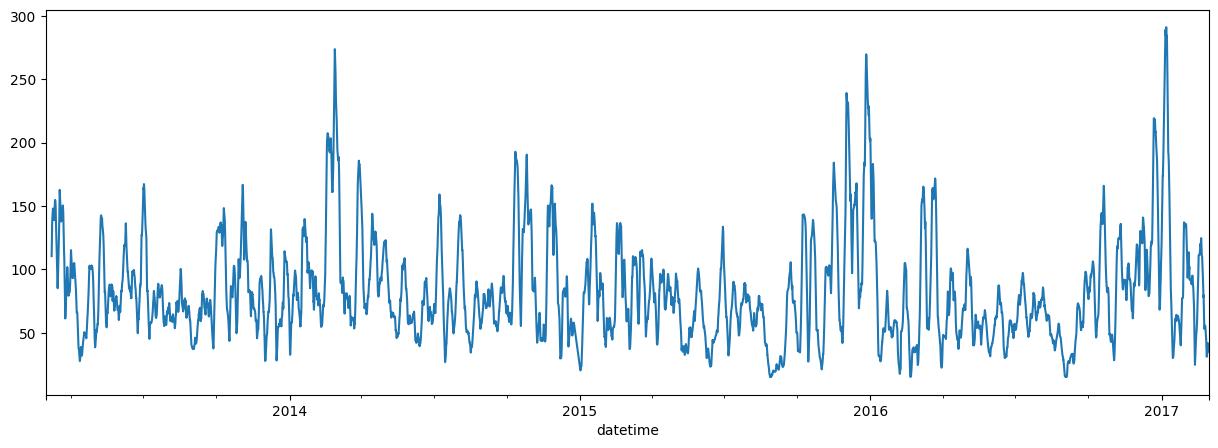

In [55]:
ts.rolling(24*7).mean().plot(figsize=(15,5))

This time we applied a rolling mean of 168 hours or 1 week, this way we remove the noise caused by daily traffic or by the day and night cycle.

When removing the daily peaks, the yearly increases are clearly visible. This confirms that the PM2.5 concentration between December and February is significantly higher than during summer time.

We previously saw some extreme outliers that even reached almost 900 $\mu g/m^3$, but in this graph, the maximum value does not even reach 300 $\mu g/m^3$. This is because the rolling mean has softened these extreme values. Now we can conclude that events of extreme pollution have a very short duration (some hours or one day), not whole weeks for example.

Lastly, it is visible that the transition between the less polluted air from summer to the highly polluted air from winter is not a progressive straight line. There are weeks during fall season when the tendency goes up and weeks when it falls before reaching winter high levels.

# ARMA

# ARIMA